## The Safest Neighborhood in Pittsburgh: Income, Greenery, & Crime
**Name:** Sammy Ramadan SJR168@pitt.edu

#Household Salary Past 12 Months

This dataset has one row per neighborhood. The income column is the total of all household incomes in that neighborhood added together.

**Source:** https://data.wprdc.org/dataset/pittsburgh-american-community-survey-2015-miscellaneous-data/resource/d159c6b3-f70a-439b-bd2b-0cb8735d76d4

In [3]:
import pandas as pd
#--------- THE INCOME DATA-----
# Loading the dataset
income_raw = pd.read_csv('wage_dataset.csv', encoding='utf-8-sig')

# View columns to confirm the correct one 
print(income_raw.columns)

#Select the relevant columns and change income column name if needed
income = income_raw[['Neighborhood', 'Estimate; Total: - With wage or salary income']]


# Rename for simplicity
income.columns = ['Neighborhood', 'Income']

# Convert income to numeric 
income.loc[:, 'Income'] = pd.to_numeric(income['Income'], errors='coerce')


#Remove missing values
income = income.dropna()

#Sort from highest to lowest income
income_ranked = income.sort_values('Income', ascending=False)

# Print top 10 neighbrohoods
print("TOP 10 neighborhoods by income:")
print(income_ranked.head(10))

# print top 3 neighborhoods
print("\nTop 3 neighborhoods by income:")
print(income_ranked.head(3))
#------CRIME DATA------
crime_raw = pd.read_csv('crime_dataset.csv', low_memory=False)

Index(['Neighborhood', 'Id', 'Estimate; Total:', 'Margin of Error; Total:',
       'Estimate; Total: - With wage or salary income',
       'Margin of Error; Total: - With wage or salary income',
       'Estimate; Total: - No wage or salary income',
       'Margin of Error; Total: - No wage or salary income'],
      dtype='object')
TOP 10 neighborhoods by income:
           Neighborhood  Income
68            Shadyside  6134.0
77  Squirrel Hill South  4999.0
13            Brookline  4545.0
9            Bloomfield  3724.0
53     Mount Washington  3274.0
15              Carrick  3065.0
7             Beechview  2719.0
36           Greenfield  2620.0
76  Squirrel Hill North  2609.0
72     South Side Flats  2604.0

Top 3 neighborhoods by income:
           Neighborhood  Income
68            Shadyside  6134.0
77  Squirrel Hill South  4999.0
13            Brookline  4545.0


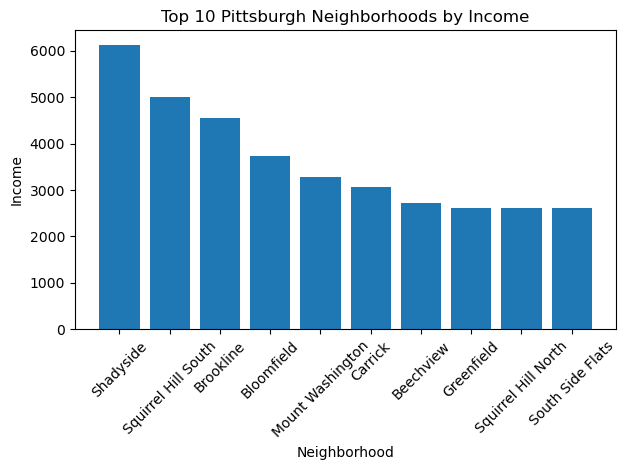

In [4]:
# bar plot  for top 10 neighborhoods
import matplotlib.pyplot as plt

#Getting the top 10
top_10_income = income_ranked.head(10)

plt.figure()

plt.bar(top_10_income['Neighborhood'], top_10_income['Income'])

plt.xticks(rotation=45)

plt.xlabel('Neighborhood')

plt.ylabel('Income')

plt.title('Top 10 Pittsburgh Neighborhoods by Income')


plt.tight_layout()
plt.show()

Crime source now https://data.wprdc.org/dataset/monthly-criminal-activity-dashboard/resource/bd41992a-987a-4cca-8798-fbe1cd946b07

In [5]:
import pandas as pd 

crime_raw = pd.read_csv('crime_dataset.csv', low_memory=False)

print(crime_raw.head())
print(crime_raw['NIBRS_Offense_Type'].value_counts())
print(crime_raw.columns)

  Report_Number ReportedDate ReportedTime  Hour DayofWeek ReportedMonth  \
0  PGHP24000024     1/1/2024        00:31     0    Monday           Jan   
1  PGHP24000024     1/1/2024        00:31     0    Monday           Jan   
2  PGHP24000024     1/1/2024        00:31     0    Monday           Jan   
3  PGHP24000024     1/1/2024        00:31     0    Monday           Jan   
4  PGHP24000017     1/1/2024        00:21     0    Monday           Jan   

                           NIBRS_Coded_Offense NIBRS_Offense_Code  \
0                       13A AGGRAVATED ASSAULT                13A   
1                             13C INTIMIDATION                13C   
2                       90Z ALL OTHER OFFENSES                90Z   
3                        23H ALL OTHER LARCENY                23H   
4  9999 Vehicle Offense (Not NIBRS Reportable)                999   

   NIBRS_Offense_Category    NIBRS_Offense_Type NIBRS_Crime_Against  \
0        Assault Offenses    Aggravated Assault              Pe

## To further extrapolate on the data, I decided to include a scoring system for crime, not just to measure all crime, but the severity as well. Because ranking crime is somewhat subjective, I decided to make the system based on qualitative crime versus quantitative crime. Where crime that is more severe takes precedence over the frequency. There is some bias to this; the system takes 70% precedence towards the quality of crime over the 30% scoring for the frequency of crimes. The reasoning behind this is that, as a team, we decided that more life-threatening crimes should matter more than common petty crimes.

In [7]:
# Crime scoring system

def crime_score(offense):
    offense = str(offense).lower()

    if 'theft' in offense or 'fraud' in offense: 
        return 1
    elif 'burglary' in offense or 'vandalism' in offense:
        return 2
    elif 'assault' in offense or 'drug' in offense:
        return 3 
    elif 'robbery' in offense or 'weapon' in offense:
        return 4 
    elif 'homicide' in offense or 'rape' in offense:
        return 5
    else:
        return 2
# Apply the scoring
crime_raw['Severity_Score'] = crime_raw['NIBRS_Offense_Type'].apply(crime_score)

In [8]:
crime_raw = pd.read_csv('crime_dataset.csv', low_memory=False)

crime_raw['Severity_Score'] = crime_raw['NIBRS_Offense_Type'].apply(crime_score)

def crime_score(offense):
    ...

print(crime_raw.columns)

# Aggregate by neighborhood
crime_summary = crime_raw.groupby('Neighborhood').agg({'Severity_Score': 'sum', 
'NIBRS_Offense_Type': 'count'
}).rename(columns={'NIBRS_Offense_Type': 'Crime_Count'})

crime_summary['Final_Score'] = (
     crime_summary['Severity_Score'] * 0.7 +
crime_summary['Crime_Count'] * 0.3
)

crime_ranked = crime_summary.sort_values('Final_Score')

print("Top 3 safest neighborhoods:")
print(crime_ranked.head(3))

Index(['Report_Number', 'ReportedDate', 'ReportedTime', 'Hour', 'DayofWeek',
       'ReportedMonth', 'NIBRS_Coded_Offense', 'NIBRS_Offense_Code',
       'NIBRS_Offense_Category', 'NIBRS_Offense_Type', 'NIBRS_Crime_Against',
       'NIBRS_Offense_Grouping', 'Violation', 'XCOORD', 'YCOORD', 'Zone',
       'Tract', 'Neighborhood', 'Block_Address', 'Severity_Score'],
      dtype='object')
Top 3 safest neighborhoods:
                Severity_Score  Crime_Count  Final_Score
Neighborhood                                            
Chartiers City              11            5          9.2
St. Clair                   27           12         22.5
Saint Clair                 54           25         45.3


This analysis uses total crime counts from the data set and my severity score without normalization due to the lack of a population column in the data set's CSV. Technically speaking, the results are correct and work the way they should, but because of the missing population column, the data favors small neighborhoods with fewer reported incidents because they're so small. To bridge the gap for the data transcrepency, I decided to include the population CSV from the WPRDC to represent crime per capita, and not artificially low crimes.

## Sub-metric 4: Population (regarding criminal data)

**Source:**  https://data.wprdc.org/dataset/2020-census-redistricting-data-extracts/resource/fb2cb765-458c-4deb-8252-0a18d7ce9a78

In [10]:
# Group by neighborhood
crime_summary = crime_raw.groupby('Neighborhood').agg({
    'Severity_Score': 'sum',
    'NIBRS_Offense_Type': 'count'
}).rename(columns={'NIBRS_Offense_Type': 'Crime_Count'})

# Load population data
city_pop = pd.read_csv('city_pop.csv')


# Merge datsets 
crime_summary = crime_summary.merge(city_pop, on='Neighborhood', how='left')

# Removes missing population 
crime_summary = crime_summary.dropna(subset=['2010_Total_Population'])

#Calculate per capita rates 
crime_summary['Crime_Rate'] = crime_summary['Crime_Count'] / crime_summary['2010_Total_Population']
crime_summary['Severity_Rate'] = crime_summary['Severity_Score'] / crime_summary['2010_Total_Population']

# Final score
crime_summary['Final_Score'] = (
    crime_summary['Severity_Rate'] * 0.7 +
    crime_summary['Crime_Rate'] * 0.3
)

# Exclude Small neighborhoods
crime_summary = crime_summary[crime_summary['2010_Total_Population'] > 2000]

crime_summary = crime_summary.reset_index()

crime_ranked = crime_summary.sort_values('Final_Score')

print("Top 3 safest neighborhoods:")
print(crime_ranked[['Neighborhood', 'Final_Score']].head(3))

Top 3 safest neighborhoods:
           Neighborhood  Final_Score
45      Stanton Heights     0.096110
43  Squirrel Hill North     0.112752
30          Morningside     0.116079
